In [52]:
import xarray as xr
from scipy.stats import pearsonr
import os.path
import datetime
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import netCDF4
import matplotlib.pyplot as plt
from matplotlib import dates
import matplotlib.cm as cm
# Generate 20 unique colors using a colormap
iro20 = cm.tab20(np.linspace(0, 1, 20))
import eatpy
from scipy.stats import qmc,spearmanr,pearsonr,iqr
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
import glob
setup_dir = "."
varname = ["1p1z_no3","1p1z_chl","1p1z_SDeN","1p1z_LDeN"]

In [62]:
# Read in the ensemble size defined in a py file.
from importlib import reload
import generate_ensemble_yaml

# Reload the module
reload(generate_ensemble_yaml)

# Access the variable through the module
N = generate_ensemble_yaml.N

In [63]:
# Read in the ensemble parameter sets defined in a csv file.
sample_scaled = pd.read_csv('parameter-values-'+str(N)+'.csv')
name_para = sample_scaled.columns.tolist() # header, parameter names
sample_scaled

,attCHL,I_thNH4,D_p5NH4,NitriR,K_NO3,K_NH4,Vp0,K_Phy,PhyIS,PhyMR,...,ZooBM,ZooER,ZooGR,ZooMR,LDeRRN,SDeRRN,CoagR,wP,wL,wS
0,0.006,0.009,0.12,0.05,4.5,2.4,2.7,5.0,0.101,0.23,...,0.03,0.11,2.0,0.04,0.099,0.089,0.661,0.51,4.5,1.21
1,0.017,0.013,0.11,0.46,4.3,2.3,1.0,1.5,0.082,0.21,...,0.22,0.32,2.1,0.33,0.111,0.033,0.520,0.61,3.9,0.94
2,0.030,0.013,0.07,0.20,4.2,3.9,3.0,1.7,0.028,0.02,...,0.19,0.06,2.6,0.17,0.307,0.016,0.512,1.33,1.4,0.62
3,0.029,0.012,0.10,0.07,3.7,1.5,2.6,0.9,0.034,0.03,...,0.32,0.26,2.7,0.12,0.023,0.006,0.809,0.60,4.1,1.25
4,0.011,0.009,0.15,0.49,2.3,3.0,1.5,2.9,0.067,0.03,...,0.12,0.16,2.1,0.14,0.431,0.026,0.722,1.04,6.4,1.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.037,0.012,0.13,0.21,4.5,3.2,2.8,3.7,0.127,0.07,...,0.03,0.31,3.2,0.32,0.412,0.041,0.059,0.61,3.7,0.51
996,0.013,0.012,0.06,0.18,2.4,3.9,2.1,1.1,0.023,0.20,...,0.02,0.27,0.3,0.06,0.169,0.062,0.621,0.16,0.9,0.55
997,0.044,0.015,0.12,0.37,0.8,2.8,3.3,3.4,0.075,0.07,...,0.20,0.32,2.5,0.24,0.201,0.072,0.477,0.69,9.4,0.77
998,0.025,0.010,0.08,0.25,3.8,2.6,1.8,0.8,0.073,0.16,...,0.01,0.35,0.9,0.34,0.089,0.045,0.185,1.25,7.9,1.00


### Read ensemble outputs and pre-processing for analysis
- remove the last time idex, which corresponds to Jan 1 of the following year but is not representative of daily mean because the simulation ends at midnight of Jan 1.
- set z as a 1d coordinate
- remove lon and lat coordinates

In [64]:
# ファイルパスのリストを作成
file_paths = sorted(glob.glob("result_[0-9][0-9][0-9][0-9].nc"))

# `xr.open_mfdataset` を使用してファイルを結合
ds = xr.open_mfdataset(
    file_paths,
    concat_dim="ensemble",
    combine="nested",
    coords="minimal",
    compat="override",
    parallel=True,
)

# 'ensemble' 次元に番号を割り当てる
ds = ds.assign_coords(ensemble=range(len(file_paths)))

# Remove the last index in the time dimension
ds = ds.isel(time=slice(None, -1))

# make z as a 1d coordinate
ds['z'] = ds['z'].isel(time=0, lat=0, lon=0)

# remove lon and lat which are arrays of size 1 (no usage)
ds = ds.squeeze()

In [65]:
ds

<xarray.Dataset> Size: 13GB
Dimensions:                                                   (ensemble: 1000,
                                                               time: 365,
                                                               z: 110, zi: 111)
Coordinates:
  * time                                                      (time) datetime64[ns] 3kB ...
    lon                                                       float32 4B 1.283
    lat                                                       float32 4B 59.33
  * z                                                         (z) float32 440B ...
    zi                                                        (time, zi) float32 162kB dask.array<chunksize=(365, 111), meta=np.ndarray>
  * ensemble                                                  (ensemble) int64 8kB ...
Data variables: (12/123)
    temp                                                      (ensemble, time, z) float32 161MB dask.array<chunksize=(1, 365, 110), meta=np.ndarray>
    salt                                                      (ensemble, time, z) float32 161MB dask.array<chunksize=(1, 365, 110), meta=np.ndarray>
    rho                                                       (ensemble, time, z) float32 161MB dask.array<chunksize=(1, 365, 110), meta=np.ndarray>
    temp_obs                                                  (ensemble, time, z) float32 161MB dask.array<chunksize=(1, 365, 110), meta=np.ndarray>
    salt_obs                                                  (ensemble, time, z) float32 161MB dask.array<chunksize=(1, 365, 110), meta=np.ndarray>
    u                                                         (ensemble, time, z) float32 161MB dask.array<chunksize=(1, 365, 110), meta=np.ndarray>
    ...                                                        ...
    1p1z_RemineL                                              (ensemble, time, z) float32 161MB dask.array<chunksize=(1, 365, 110), meta=np.ndarray>
    1p1z_Nitrifi                                              (ensemble, time, z) float32 161MB dask.array<chunksize=(1, 365, 110), meta=np.ndarray>
    light_par                                                 (ensemble, time, z) float32 161MB dask.array<chunksize=(1, 365, 110), meta=np.ndarray>
    attenuation_coefficient_of_photosynthetic_radiative_flux  (ensemble, time, z) float32 161MB dask.array<chunksize=(1, 365, 110), meta=np.ndarray>
    surface_drag_coefficient_in_air                           (ensemble, time) float32 1MB dask.array<chunksize=(1, 365), meta=np.ndarray>
    surface_albedo                                            (ensemble, time) float32 1MB dask.array<chunksize=(1, 365), meta=np.ndarray>
Attributes:
    title:    GOTM Simulation
    comment:  file created by flexout - https://github.com/BoldingBruggeman/f...

### Sea surface chlorophyll-a sensitivity

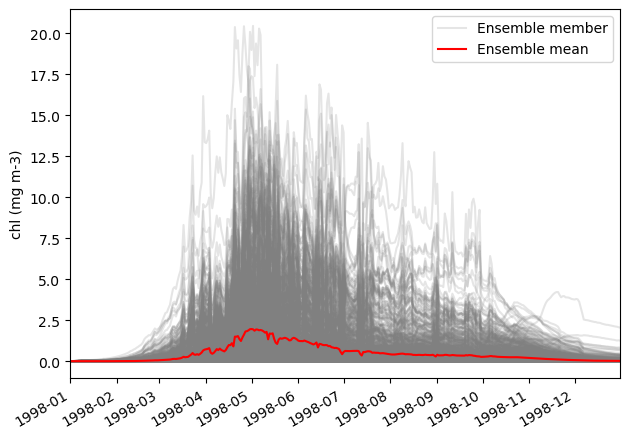

In [67]:
fig = plt.figure()
# loop over ensemble members
for j in range(ds['ensemble'].size):
    plt.plot(ds['time'],ds['1p1z_chl'].isel(ensemble=j,z=-1),c='gray',alpha=0.2)
plt.plot([],[],c='gray',alpha=0.2,label='Ensemble member')
plt.plot(ds['time'],ds['1p1z_chl'].isel(z=-1).mean(dim='ensemble'),label='Ensemble mean',color='r')
plt.ylabel('chl (mg m-3)')
plt.legend()
plt.xlim(ds['time'].isel(time=0),ds['time'].isel(time=-1))
plt.tight_layout()
fig.autofmt_xdate()
plt.savefig('fig-SSCHL-'+str(N),dpi=300,bbox_inches='tight')

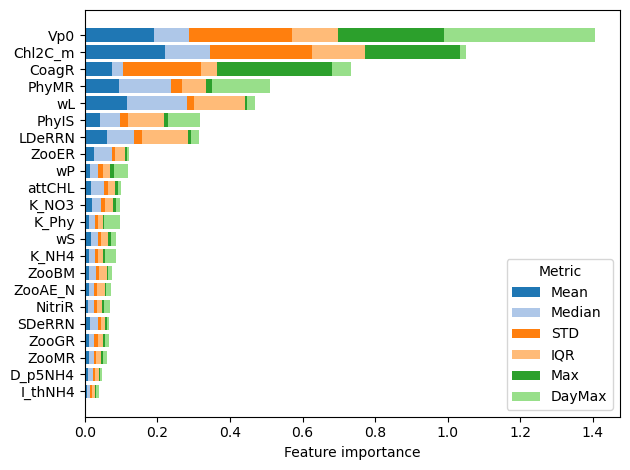

In [68]:
sschl = ds['1p1z_chl'].isel(z=-1)

# calculate different metrics
n_metric = ['Mean','Median','STD','IQR','Max','DayMax']
v_metric = [sschl.mean(dim='time'),
            sschl.median(dim='time'),
            sschl.std(dim='time'),
            sschl.quantile(0.75, dim='time')-sschl.quantile(0.25, dim='time'),
            sschl.max(dim='time'),
            sschl.argmax(dim='time') # note this is the index and not the datetime so that correlation can be calculated
           ]

df = pd.DataFrame({"Parameter": name_para})

for j in range(np.size(n_metric)):

    rf = RandomForestRegressor()
    rf.fit(sample_scaled, v_metric[j])
    df[n_metric[j]] = rf.feature_importances_
df['total'] = df[n_metric].sum(axis=1)    
df = df.sort_values(by="total", ascending=True)

plt.figure()
sum_prev = np.zeros(len(name_para))
for j in range(len(n_metric)):
    plt.barh(width=df[n_metric[j]],y=df['Parameter'],left=sum_prev,label=n_metric[j],color=iro20[j])
    sum_prev += df[n_metric[j]]

plt.xlabel('Feature importance')
plt.legend(title='Metric')
plt.tight_layout()
plt.savefig('fig-sensitivity-SSCHL-'+str(N),dpi=300,bbox_inches='tight')

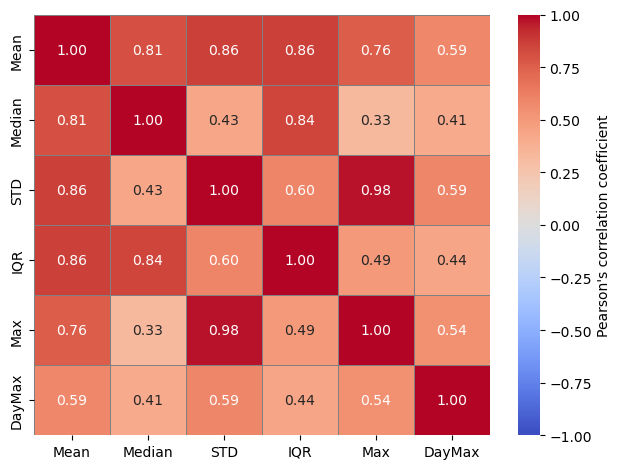

In [69]:
corr_matrix = df.drop(columns=['Parameter','total']).corr(method='pearson')
# Set the figure size
plt.figure()

# Create a heatmap
sns.heatmap(
    corr_matrix,
    annot=True,  # Show correlation values in the cells
    cmap='coolwarm',  # Color map (red for negative, blue for positive)
    center=0,  # Center the color map at 0
    vmin=-1,  # Minimum correlation value
    vmax=1,  # Maximum correlation value
    fmt=".2f",  # Format annotations to 2 decimal places
    linewidths=0.5,  # Add lines between cells
    linecolor='gray',  # Color of the lines
    cbar_kws={"label": "Pearson's correlation coefficient"}  # Add title to the colorbar
)
plt.tight_layout()
plt.savefig('fig-metric-correlation-'+str(N),dpi=300,bbox_inches='tight')

### Sea surface chlorophyll-a sensitivity at different lead times/months
- target: monthly mean

<Figure size 640x480 with 0 Axes>

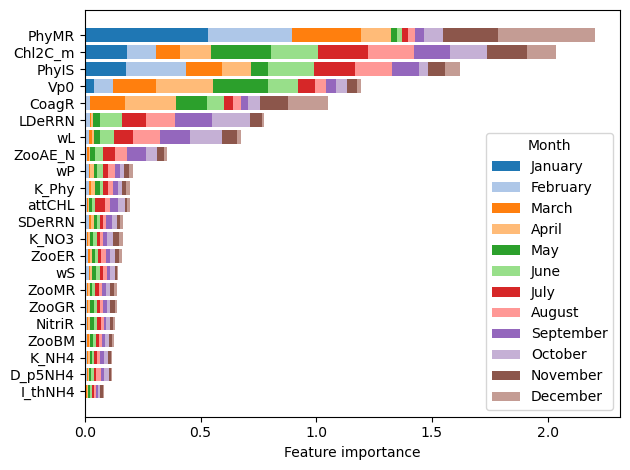

In [46]:
target = ds["1p1z_chl"].isel(z=-1,lat=0,lon=0).groupby('time.month').mean(dim='time')

tsuki = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

df = pd.DataFrame({"Parameter": name_para})


fig = plt.figure()

for j in range(len(tsuki)):
    rf = RandomForestRegressor()
    rf.fit(sample_scaled, target[:,j])
    df[tsuki[j]] = rf.feature_importances_
df['total'] = df[tsuki].sum(axis=1)    
df = df.sort_values(by="total", ascending=True)

plt.figure()
sum_prev = np.zeros(len(name_para))
for j in range(len(tsuki)):
    plt.barh(width=df[tsuki[j]],y=df['Parameter'],left=sum_prev,label=tsuki[j],color=iro20[j])
    sum_prev += df[tsuki[j]]

plt.xlabel('Feature importance')
plt.legend(title='Month')
plt.tight_layout()
plt.savefig('fig-sensitivity-month-SSCHL-'+str(N),dpi=300,bbox_inches='tight')

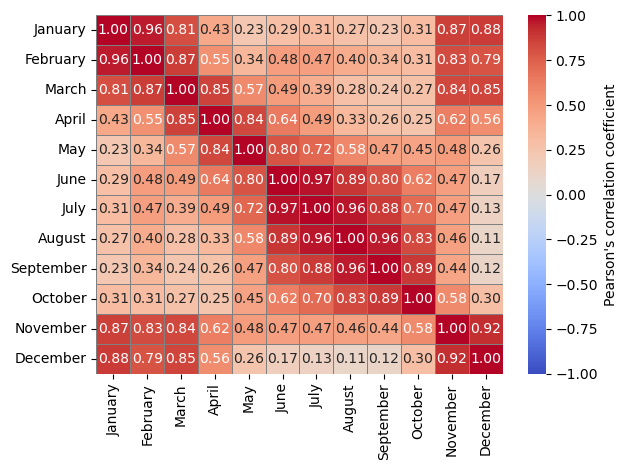

In [82]:
corr_matrix = df.drop(columns=['Parameter','total']).corr(method='pearson')
# Set the figure size
plt.figure()

# Create a heatmap
sns.heatmap(
    corr_matrix,
    annot=True,  # Show correlation values in the cells
    cmap='coolwarm',  # Color map (red for negative, blue for positive)
    center=0,  # Center the color map at 0
    vmin=-1,  # Minimum correlation value
    vmax=1,  # Maximum correlation value
    fmt=".2f",  # Format annotations to 2 decimal places
    linewidths=0.5,  # Add lines between cells
    linecolor='gray',  # Color of the lines
    cbar_kws={"label": "Pearson's correlation coefficient"}  # Add title to the colorbar
)
plt.tight_layout()
plt.savefig('fig-month-correlation-'+str(N),dpi=300,bbox_inches='tight')

### Variable-dependence on sensitivity
- target: upper 50-m average BGC variables

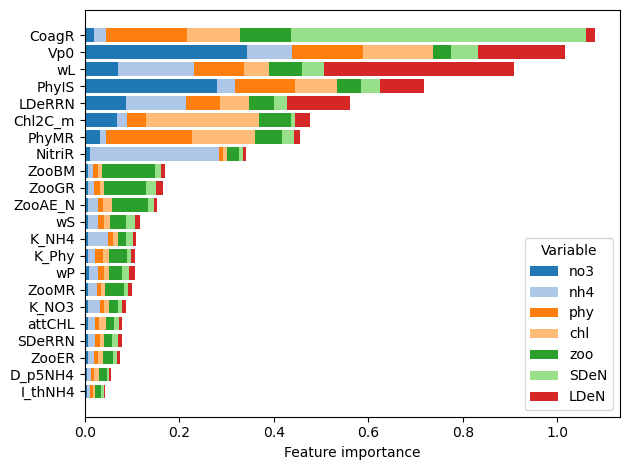

In [58]:
varlist = ["no3","nh4","phy","chl","zoo","SDeN","LDeN"]
unilist = ["mmol m$^{-3}$","mmol m$^{-3}$","mmol m$^{-3}$","mg m$^{-3}$","mmol m$^{-3}$","mmol m$^{-3}$","mmol m$^{-3}$"]

df = pd.DataFrame({"Parameter": name_para})
for j in range(len(varlist)):
    target = ds['1p1z_'+varlist[j]].sel(z=slice(-50,None)).mean(dim=['time'])

#    rf = RandomForestRegressor()
    rf = MultiOutputRegressor(RandomForestRegressor())
    rf.fit(sample_scaled, target)
#    df[varlist[j]] = rf.feature_importances_
    # Access feature importances from the underlying estimators
    # Option 1: Average feature importances across all outputs
    avg_feature_importances = np.mean([est.feature_importances_ for est in rf.estimators_], axis=0)
    df[varlist[j]] = avg_feature_importances
df['total'] = df[varlist].sum(axis=1)    
df = df.sort_values(by="total", ascending=True)

plt.figure()
sum_prev = np.zeros(len(name_para))
for j in range(len(varlist)):
    plt.barh(width=df[varlist[j]],y=df['Parameter'],left=sum_prev,label=varlist[j],color=iro20[j])
    sum_prev += df[varlist[j]]

plt.xlabel('Feature importance')
plt.legend(title='Variable')
plt.tight_layout()
plt.savefig('fig-sensitivity-variables-'+str(N),dpi=300,bbox_inches='tight')

### same as above but for vertically averaged.
- takehome: the first few important parameters are the same as above.

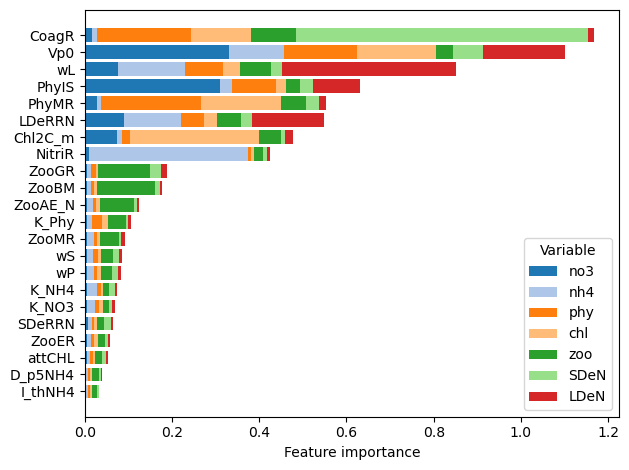

In [59]:
varlist = ["no3","nh4","phy","chl","zoo","SDeN","LDeN"]
unilist = ["mmol m$^{-3}$","mmol m$^{-3}$","mmol m$^{-3}$","mg m$^{-3}$","mmol m$^{-3}$","mmol m$^{-3}$","mmol m$^{-3}$"]

df = pd.DataFrame({"Parameter": name_para})
for j in range(len(varlist)):
    target = ds['1p1z_'+varlist[j]].sel(z=slice(-50,None)).mean(dim=['time','z'])

    rf = RandomForestRegressor()
#    rf = MultiOutputRegressor(RandomForestRegressor())
    rf.fit(sample_scaled, target)
    df[varlist[j]] = rf.feature_importances_
    # Access feature importances from the underlying estimators
    # Option 1: Average feature importances across all outputs
#    avg_feature_importances = np.mean([est.feature_importances_ for est in rf.estimators_], axis=0)
#    df[varlist[j]] = avg_feature_importances
df['total'] = df[varlist].sum(axis=1)    
df = df.sort_values(by="total", ascending=True)

plt.figure()
sum_prev = np.zeros(len(name_para))
for j in range(len(varlist)):
    plt.barh(width=df[varlist[j]],y=df['Parameter'],left=sum_prev,label=varlist[j],color=iro20[j])
    sum_prev += df[varlist[j]]

plt.xlabel('Feature importance')
plt.legend(title='Variable')
plt.tight_layout()
plt.savefig('fig-sensitivity-variables-50maveraged-'+str(N),dpi=300,bbox_inches='tight')

### for each month and variable

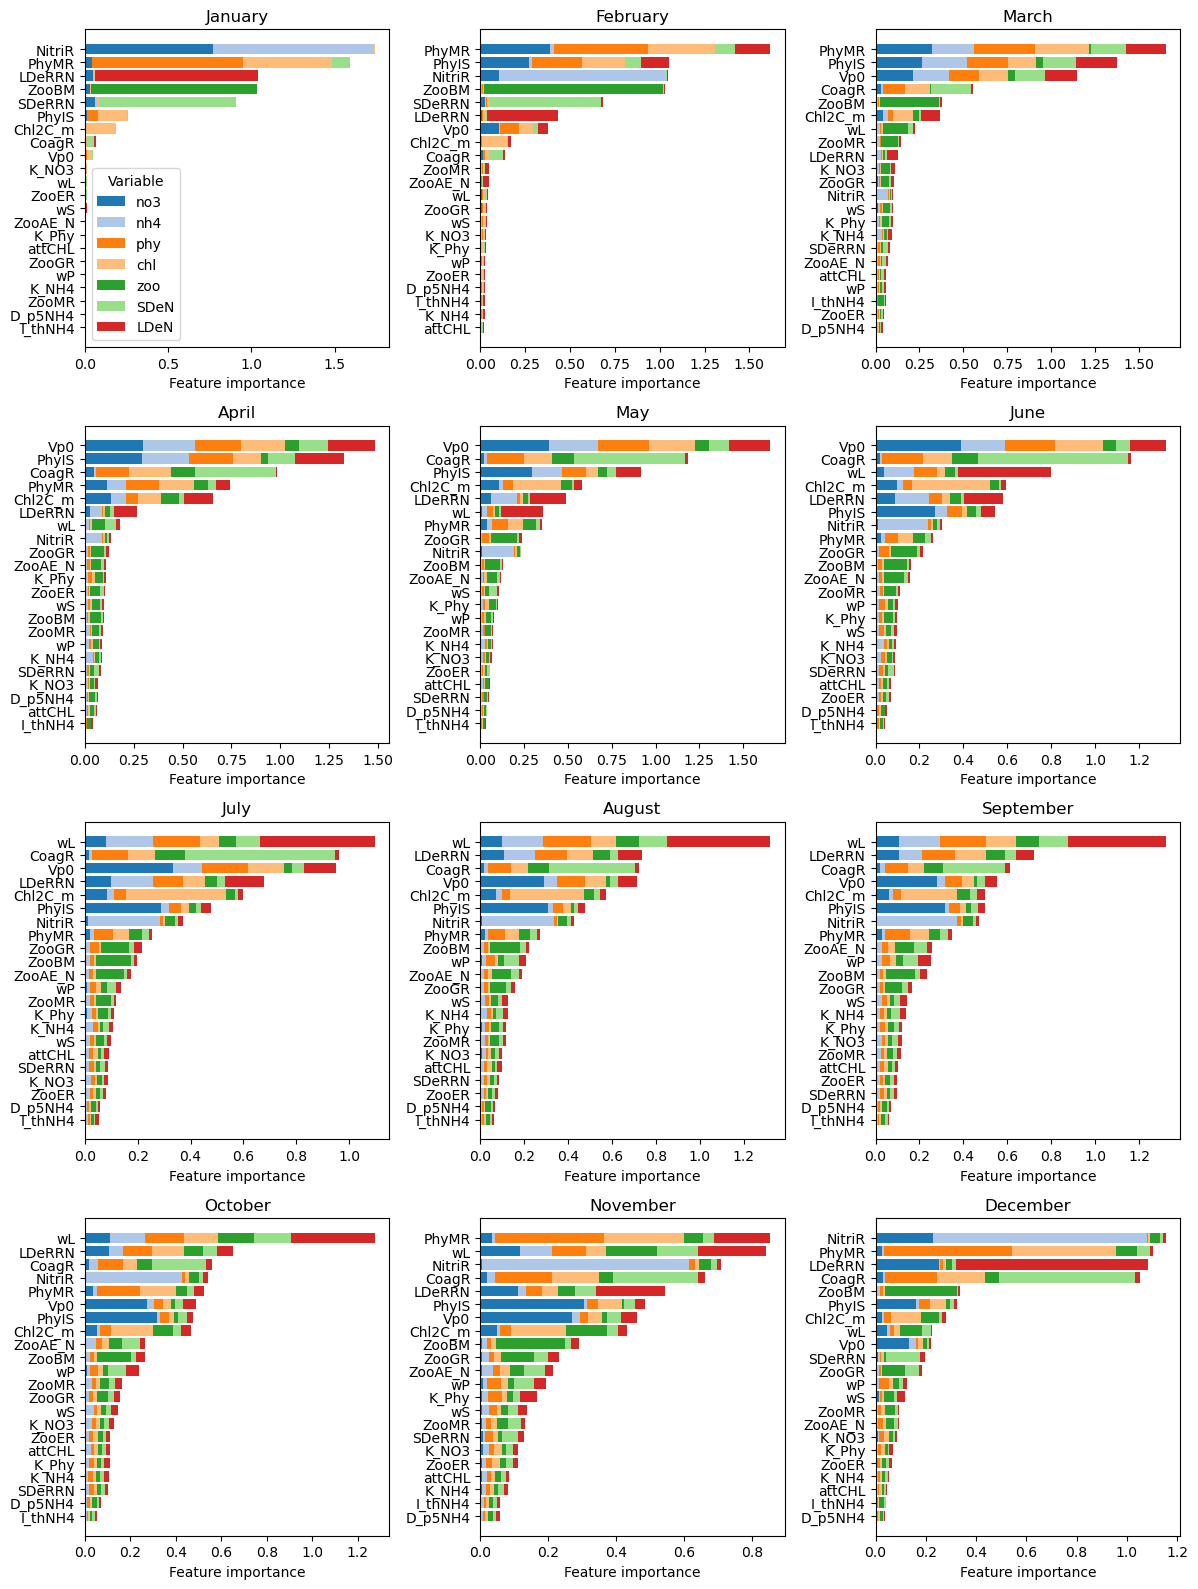

In [61]:
tsuki = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

varlist = ["no3","nh4","phy","chl","zoo","SDeN","LDeN"]
unilist = ["mmol m$^{-3}$","mmol m$^{-3}$","mmol m$^{-3}$","mg m$^{-3}$","mmol m$^{-3}$","mmol m$^{-3}$","mmol m$^{-3}$"]

#monthly mean output
targetmm = ds.groupby('time.month').mean('time')
fig = plt.figure(figsize=(12,16))
for i in range(len(tsuki)):
    plt.subplot(4,3,i+1)
    plt.title(tsuki[i])
    df = pd.DataFrame({"Parameter": name_para})
    for j in range(len(varlist)):
        target = targetmm['1p1z_'+varlist[j]].sel(z=slice(-50,None)).isel(month=i).mean(dim=['z'])    
        rf = RandomForestRegressor()
        rf.fit(sample_scaled, target)
        df[varlist[j]] = rf.feature_importances_
    df['total'] = df[varlist].sum(axis=1)    
    df = df.sort_values(by="total", ascending=True)
        
    sum_prev = np.zeros(len(name_para))
    for j in range(len(varlist)):
        plt.barh(width=df[varlist[j]],y=df['Parameter'],left=sum_prev,label=varlist[j],color=iro20[j])
        sum_prev += df[varlist[j]]

    plt.xlabel('Feature importance')
    if i==0:
        plt.legend(title='Variable')
plt.tight_layout()
plt.savefig('fig-sensitivity-month-variable-50maveraged-'+str(N),dpi=300,bbox_inches='tight')

### Biogeochemical ensemble mean and STD (this can take a long time to plot when ensemble size is large)
- take-home: upper 50 m is most important

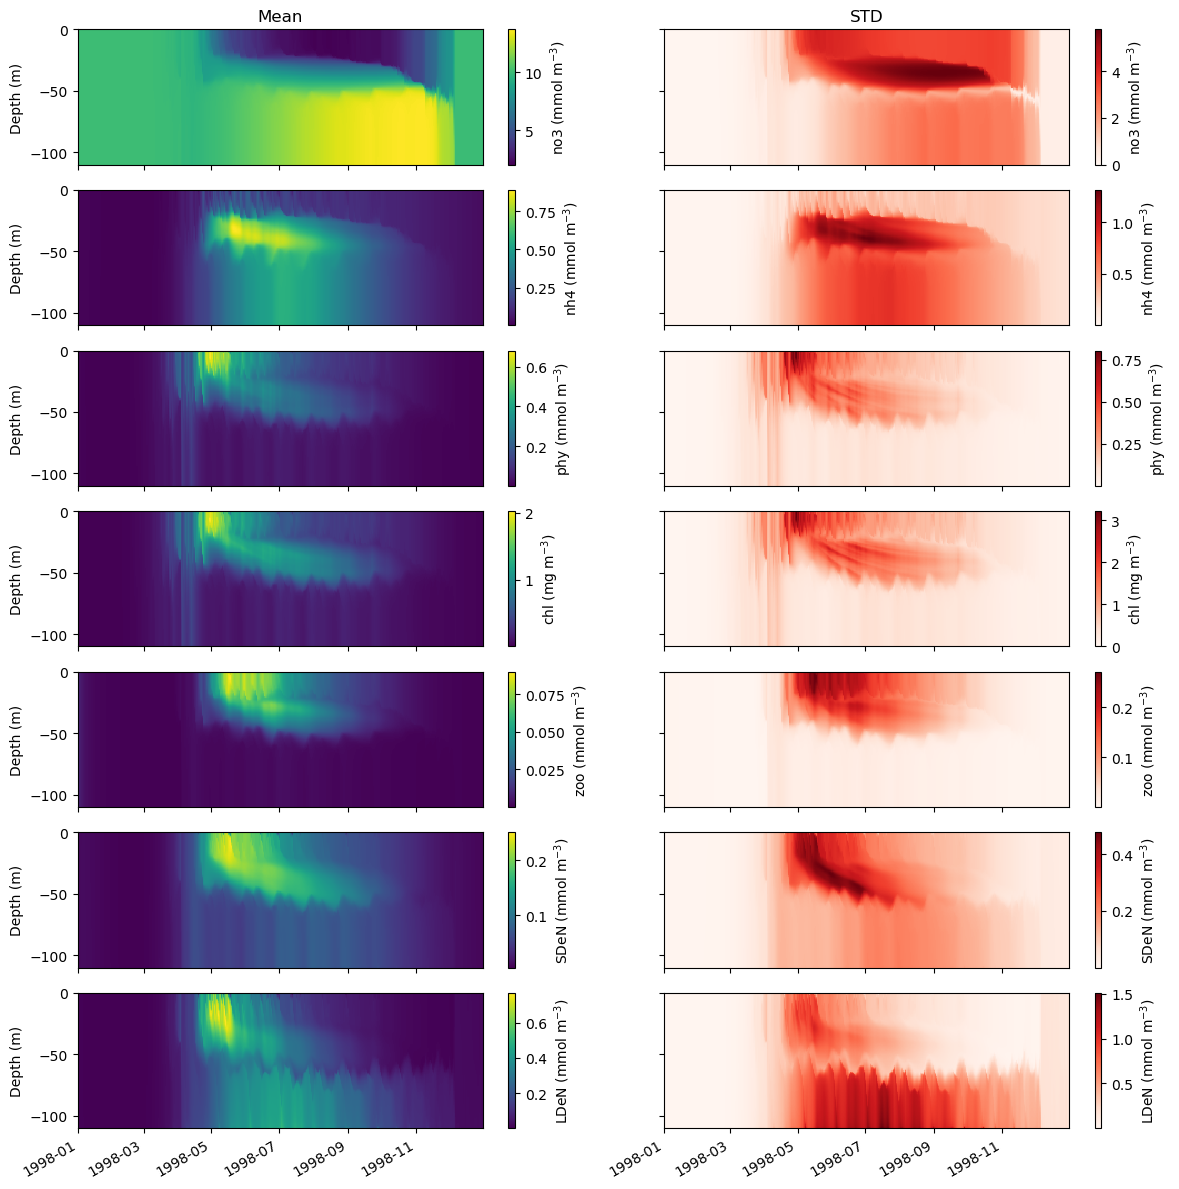

In [89]:
varlist = ["no3","nh4","phy","chl","zoo","SDeN","LDeN"]
unilist = ["mmol m$^{-3}$","mmol m$^{-3}$","mmol m$^{-3}$","mg m$^{-3}$","mmol m$^{-3}$","mmol m$^{-3}$","mmol m$^{-3}$"]

fig, axs = plt.subplots(7, 2, figsize=(12,12), sharex=True, sharey=True)

for j in range(len(varlist)):
    output = ds['1p1z_'+varlist[j]]

    mesh = axs[j, 0].pcolormesh(time,z,np.squeeze(output.mean(axis=0)).T)
    plt.colorbar(mesh).set_label(varlist[j]+' ('+unilist[j]+')')
    axs[j, 0].set_ylabel('Depth (m)')
    if j == 0:
        axs[j, 0].set_title('Mean')
    mesh = axs[j, 1].pcolormesh(time,z,np.squeeze(output.std(axis=0)).T,cmap='Reds')
    plt.colorbar(mesh).set_label(varlist[j]+' ('+unilist[j]+')')
    if j == 0:
        axs[j, 1].set_title('STD')

fig.autofmt_xdate()
plt.tight_layout()
# Manually adjust spacing (left, bottom, right, top, wspace, hspace)
#plt.subplots_adjust(wspace=0.15)  # Adjust vertical spacing between subplots

fig.savefig('fig-tz-bgc-'+str(N),dpi=300,bbox_inches='tight')

### Background physical environment (temperature, salinity, and density)

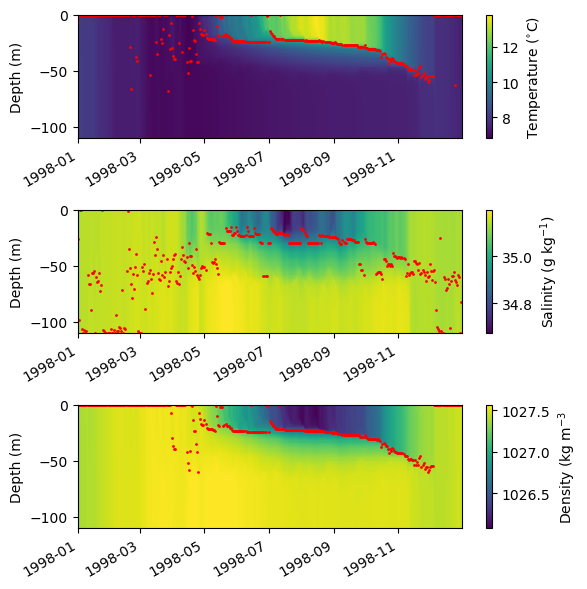

In [92]:
fig, axs = plt.subplots(3, 1, figsize=(6,6))

mesh = axs[0].pcolormesh(time,z,ds['temp'][0,:,:,0,0].T)
plt.colorbar(mesh).set_label('Temperature ($^{\circ}$C)')
axs[0].set_ylabel('Depth (m)')
mesh = axs[1].pcolormesh(time,z,ds['salt'][0,:,:,0,0].T)
plt.colorbar(mesh).set_label('Salinity (g kg$^{-1}$)')
axs[1].set_ylabel('Depth (m)')
mesh = axs[2].pcolormesh(time,z,ds['rho'][0,:,:,0,0].T)
plt.colorbar(mesh).set_label('Density (kg m$^{-3}$')
axs[2].set_ylabel('Depth (m)')

thermocline_depth = np.zeros(len(time))  # Array to store thermocline depths
halocline_depth = np.zeros(len(time))  # Array to store thermocline depths
pycnocline_depth = np.zeros(len(time))  # Array to store thermocline depths
for t in range(len(time)):
    gradient = np.gradient(ds['temp'][0,t,:,0,0], z, axis=0)
    max_gradient_index = np.argmax(np.abs(gradient))
    thermocline_depth[t] = z[max_gradient_index]
    gradient = np.gradient(ds['salt'][0,t,:,0,0], z, axis=0)
    max_gradient_index = np.argmax(np.abs(gradient))
    halocline_depth[t] = z[max_gradient_index]
    gradient = np.gradient(ds['rho'][0,t,:,0,0], z, axis=0)
    max_gradient_index = np.argmax(np.abs(gradient))
    pycnocline_depth[t] = z[max_gradient_index]
mesh = axs[0].scatter(time,thermocline_depth,c='r',s=1)
mesh = axs[1].scatter(time,halocline_depth,c='r',s=1)
mesh = axs[2].scatter(time,pycnocline_depth,c='r',s=1)

fig.autofmt_xdate()
plt.tight_layout()

fig.savefig('fig-tz-tsrho-'+str(N),dpi=300,bbox_inches='tight')